Please Enter the no of qubits= 12


Alice message as List= [0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1] 

QuantumRegister(12, 'q74') ClassicalRegister(12, 'c25')

 Alice message as string = 011111100011


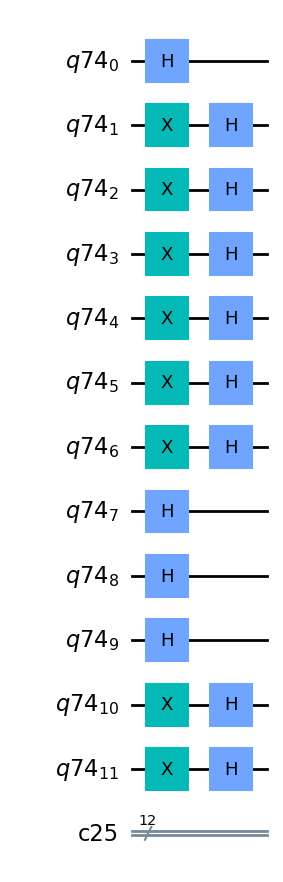

        ┌───┐     
 q74_0: ┤ H ├─────
        ├───┤┌───┐
 q74_1: ┤ X ├┤ H ├
        ├───┤├───┤
 q74_2: ┤ X ├┤ H ├
        ├───┤├───┤
 q74_3: ┤ X ├┤ H ├
        ├───┤├───┤
 q74_4: ┤ X ├┤ H ├
        ├───┤├───┤
 q74_5: ┤ X ├┤ H ├
        ├───┤├───┤
 q74_6: ┤ X ├┤ H ├
        ├───┤└───┘
 q74_7: ┤ H ├─────
        ├───┤     
 q74_8: ┤ H ├─────
        ├───┤     
 q74_9: ┤ H ├─────
        ├───┤┌───┐
q74_10: ┤ X ├┤ H ├
        ├───┤├───┤
q74_11: ┤ X ├┤ H ├
        └───┘└───┘
c25: 12/══════════
                  
Alice_circuit =
         ┌───┐     
 q74_0: ┤ H ├─────
        ├───┤┌───┐
 q74_1: ┤ X ├┤ H ├
        ├───┤├───┤
 q74_2: ┤ X ├┤ H ├
        ├───┤├───┤
 q74_3: ┤ X ├┤ H ├
        ├───┤├───┤
 q74_4: ┤ X ├┤ H ├
        ├───┤├───┤
 q74_5: ┤ X ├┤ H ├
        ├───┤├───┤
 q74_6: ┤ X ├┤ H ├
        ├───┤└───┘
 q74_7: ┤ H ├─────
        ├───┤     
 q74_8: ┤ H ├─────
        ├───┤     
 q74_9: ┤ H ├─────
        ├───┤┌───┐
q74_10: ┤ X ├┤ H ├
        ├───┤├───┤
q74_11: ┤ X ├┤ H ├
        └───┘└

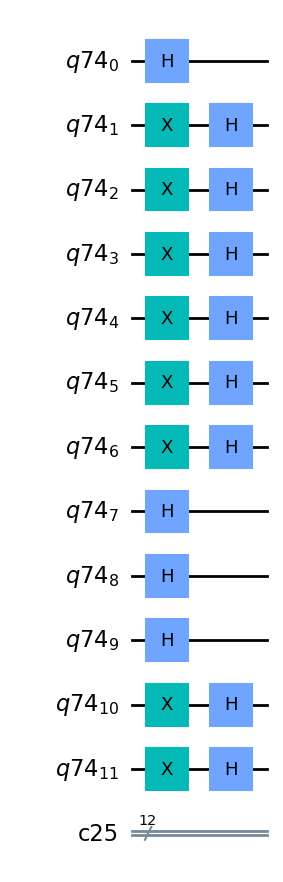

Alice sent: 011111100011
Bob received: 011111100011


In [38]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, execute, Aer
from random import randrange

no_qubits=int(input("Please Enter the no of qubits="))

qreg = QuantumRegister(no_qubits) # quantum register with 8/16/ qubits
creg = ClassicalRegister(no_qubits) # classical register with 8/16 

def print_outcomes_in_reserve(counts): # takes a dictionary variable
    for outcome in counts: # for each key value in the dictionary
        reverse_outcome = ''
        for i in outcome: #, each string can be considered as a list of characters
            reverse_outcome = i + reverse_outcome # each new symbol comes before the old symbol(s)
    return reverse_outcome
pass

def SendState(qc1, qc2, qc1_name):
    print("Alice_circuit =\n",qc1)
    print("\n Bob_circuit=\n",qc2)
    #display(qc2.draw('mpl'))
    ''' This function takes the output of a circuit qc1 (made up only of x and 
        h gates and initializes another circuit qc2 with the same state
    ''' 
    
    # Quantum state(qs) is retrieved from qasm(simulator) code of qc1(quantum circuit_1)
    qs = qc1.qasm().split(sep=';')[4:-1]
    print(qs)

    # Process the code to get the instructions
    for index, instruction in enumerate(qs):
        qs[index] = instruction.lstrip()
        print(qs[index])

    for instruction in qs:
        if instruction[0] == 'x':
            if instruction[5] == '[':
                old_qr = int(instruction[6:-1])
                print(old_qr)
            else:
                old_qr = int(instruction[5:-1])
                print(old_qr)
            qc2.x(qreg[old_qr])
        elif instruction[0] == 'h':
            if instruction[5] == '[':
                old_qr = int(instruction[6:-1])
                print(old_qr)
            else:
                old_qr = int(instruction[5:-1])
                print(old_qr)
            qc2.h(qreg[old_qr])
        elif instruction[0] == 'm': # exclude measuring:
            pass
        else:
            raise Exception('Unable to parse instruction')
pass

def create_circuit_Alice(no_qubits):
    # Quantum circuit for Alice state
    Alice_circuit = QuantumCircuit(qreg, creg, name='Alice')
    Alice_send=plain_text_meassge()
    print("Alice message as List=",Alice_send,"\n")
    
    #Creating random bit string
    for i in range(len(Alice_send)):
        bit =int(Alice_send[i])
        #Alice_send.append(bit)
        #print(bit)
        #Apply X gate if the bit is equal to 1
        if bit==1:
            Alice_circuit.x(qreg[i])
    print(qreg,creg)
    #list to string conversion
    send_str = ''.join(str(e) for e in Alice_send)
    print("\n","Alice message as string =",send_str)
    #Alice_circuit.barrier()
    #qubits are initialized as |0> and |1> basis(Rectilinear basis/Z-basis) ,apply Hadamard gate H switch to X-basis( diagonal basis ,|+> and |->)
    
    Alice_circuit.h(qreg)
    display(Alice_circuit.draw('mpl'))
    create_circuit_Bob(Alice_circuit,send_str)
    #print(Alice_circuit)
    return Alice_circuit ,send_str
pass

     
def create_circuit_Bob(Alice_circuit,send_str):
    print(Alice_circuit)
    Bob_circuit = QuantumCircuit(qreg, creg, name='Bob') #Defining Bob circuit
    SendState(Alice_circuit, Bob_circuit, 'Alice') #Alice sends states to Bob
    display(Bob_circuit.draw("mpl"))
    
    #Applying H gate first
    Bob_circuit.h(qreg)
    #then continue with regular measurement
    Bob_circuit.measure(qreg,creg) 

    job = execute(Bob_circuit,Aer.get_backend('qasm_simulator'),shots=1) #Note that Balvis only has one shot to measure qubits
    counts = job.result().get_counts(Bob_circuit) # counts is a dictionary object in python
    received = print_outcomes_in_reserve(counts)

    print("Alice sent:", send_str)
    print("Bob received:", received)
pass
    
def plain_text_meassge():
    Alice_send=[] #Initial bit string to send
    #Creating random bit string
    for i in range(no_qubits):
        bit = randrange(2)
        Alice_send.append(bit)
    #print(Alice_send)
    return Alice_send
pass
    
 
def main():
    Alice_circuit=create_circuit_Alice(no_qubits)
    #print(Alice_circuit)
    #create_circuit_Bob(Alice_circuit,send_str)
    pass
    
main()